In [ ]:
import marimo as mo
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from regex import P
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from itertools import combinations
from tqdm import tqdm
import os
import re
import yaml
from torchgeodemo import autoencoder_train_latent
import torch
import os
import gdown


#notebook to rest reconstruction error of PCA

random_seed_number = 20210321  # 2021 UK Census date used as random seed
def set_random_seeds(seed):
    # """Set random seeds for reproducibility."""
    torch.manual_seed(seed)  # Set seed for PyTorch
    # np.random.seed(seed)  # Set seed for NumPy
    # random.seed(seed)  # Set seed for Python's random module

    # # If using a GPU, set seeds for CUDA as well
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # # Ensure deterministic behavior on GPU
    # torch.backends.cudnn.deterministic = True  # Make sure CUDA uses deterministic algorithms
    # torch.backends.cudnn.benchmark = False  # Avoid using CUDA's autotuning for performance (slower, but more reproducible)

# Set the seed
set_random_seeds(seed=random_seed_number)

cleaned_data_path = "../data/engcensus_cleaned_scaled.parquet"


In [4]:
#load the cleaned data
df_scaled = pd.read_parquet(cleaned_data_path)
df_scaled

,OA,ts0010002_PCT,ts0010003_PCT,ts0020002_PCT,ts0020003_PCT,ts0020004_PCT,ts0020005_PCT,ts0020006_PCT,ts0020007_PCT,ts0020008_PCT,...,ts0670007_PCT,ts0670008_PCT,ts0680002_PCT,ts0680003_PCT,ts0750002_PCT,ts0750003_PCT,ts0750004_PCT,ts0750005_PCT,ts0750006_PCT,ts0750007_PCT
0,E00060274,1.0,0.0,0.497,0.301,0.301,0.301,0.000,0.000,0.000,...,0.146,0.042,0.275,0.725,0.259,0.000,0.241,0.384,0.116,0.000
1,E00060275,1.0,0.0,0.508,0.344,0.331,0.325,0.007,0.013,0.000,...,0.184,0.016,0.251,0.749,0.217,0.025,0.280,0.325,0.153,0.000
2,E00060276,1.0,0.0,0.366,0.437,0.432,0.432,0.000,0.005,0.000,...,0.178,0.023,0.166,0.834,0.287,0.000,0.374,0.296,0.035,0.009
3,E00060277,1.0,0.0,0.464,0.368,0.368,0.368,0.000,0.000,0.000,...,0.163,0.014,0.245,0.755,0.336,0.008,0.295,0.238,0.123,0.000
4,E00060279,1.0,0.0,0.388,0.415,0.415,0.415,0.000,0.000,0.000,...,0.163,0.027,0.202,0.798,0.281,0.017,0.347,0.240,0.116,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188875,W00006938,1.0,0.0,0.240,0.542,0.542,0.542,0.000,0.000,0.000,...,0.396,0.005,0.160,0.840,0.333,0.010,0.275,0.216,0.167,0.000
188876,W00006940,1.0,0.0,0.302,0.509,0.503,0.500,0.003,0.006,0.006,...,0.273,0.038,0.181,0.819,0.254,0.034,0.277,0.288,0.147,0.000
188877,W00006941,1.0,0.0,0.393,0.363,0.363,0.355,0.009,0.000,0.000,...,0.197,0.047,0.139,0.861,0.326,0.031,0.209,0.279,0.147,0.008
188878,W00006942,1.0,0.0,0.479,0.335,0.335,0.335,0.000,0.000,0.000,...,0.160,0.043,0.240,0.760,0.269,0.023,0.169,0.415,0.115,0.008


In [8]:
def gen_layer_sizes(input_size,latent_size,num_layers,scaling_type = "mul"):

    """
    Generate layer sizes for a neural network based on the input size, latent size, number of layers, and scaling type.

    Args:
        input_size (int): The size of the input layer.
        latent_size (int): The size of the latent layer.
        num_layers (int): The number of layers in the network.
        scaling_type (str): The type of scaling to use. Can be "geo" or "lin".

    Returns:
        list: A list containing the sizes of each layer in the network.
    """
    if scaling_type == "mul":
        # Geometric scaling
        scale_factor = (latent_size / input_size) ** (1 / (num_layers - 1))
        layer_sizes = [int(input_size * scale_factor ** i) for i in range(num_layers)]
    elif scaling_type == "lin":
        # Linear scaling
        step = (latent_size - input_size) / (num_layers - 1)
        layer_sizes = [int(input_size + step * i) for i in range(num_layers)]
    else:
        raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

    #for torchgeodemo dont want to include the input layer
    layer_sizes = layer_sizes[1:]  # Exclude input layer size
    return layer_sizes




In [58]:

run_name = "60epoch_depthscan_alleng_lin"
WORKING_DIR = "../engcensus/" + run_name
os.makedirs(WORKING_DIR, exist_ok=True)
# Output directory for generated YAMLs
OUTPUT_DIR = "../engcensus/" + run_name + "/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)

epochs = 60

input_size = len(df_scaled.columns)-1
encoder_layer_sizes = []
bottleneck_size = 32
depths = [2,3,4,6,8]
for depth in depths:
    encoder_layer_sizes.append(gen_layer_sizes(input_size, bottleneck_size, depth, scaling_type="lin"))

def plot_loss(WORKING_DIR,data_nickname,ae_nickname):
    # Load the loss data
    loss_data = pd.read_csv(WORKING_DIR + f"/logs/log_{data_nickname}_{ae_nickname}_v1/version_1/metrics.csv")[['epoch', 'train_loss_epoch', 'recon_loss_epoch']]
    #drop rows with nan
    loss_data = loss_data.dropna()
    plt.plot(loss_data["epoch"], loss_data["train_loss_epoch"], label="Training Loss")
    plt.plot(loss_data["epoch"], loss_data["recon_loss_epoch"], label="Reconstruction Loss")
    plt.show()



geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [32]}, 'max_epochs': 60, 'nickname': 'bottleneck_32_depth2', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}




ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=32, bias=True)
      (1): Identity()
    )
  )
  (decoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=32, out_features=429, bias=True)
      (1): Identity()
    )
  )
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 13.8 K | train
2 | decoder       | MLP     | 14.2 K | train
--------------------------------------------------
27.9 K    Trainable params
0         Non-trainable params
27.9 K    Total params
0.112     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth2_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth2_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth2_v1__reconstructed_outputs.csv


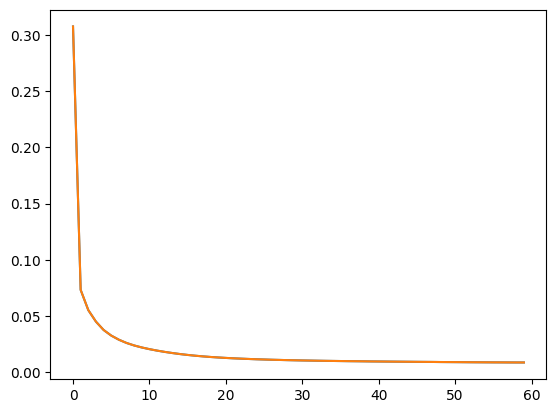


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 230]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [230, 32]}, 'max_epochs': 60, 'nickname': 'bottleneck_32_depth3', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 230, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=230, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=230, out_features=32, bias=True)
      (3): Identity()
    )
  )
  (decoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=32, out_features=

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 106 K  | train
2 | decoder       | MLP     | 106 K  | train
--------------------------------------------------
212 K     Trainable params
0         Non-trainable params
212 K     Total params
0.852     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth3_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth3_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth3_v1__reconstructed_outputs.csv


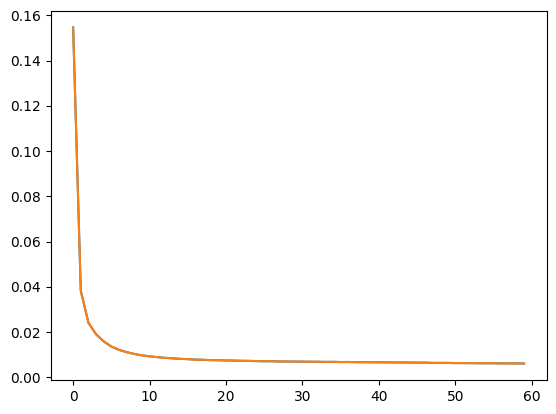


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 164, 296]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [296, 164, 32]}, 'max_epochs': 60, 'nickname': 'bottleneck_32_depth4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 164, 296, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=296, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=296, out_features=164, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=164, out_features=32, bias=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 181 K  | train
2 | decoder       | MLP     | 181 K  | train
--------------------------------------------------
362 K     Trainable params
0         Non-trainable params
362 K     Total params
1.452     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth4_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth4_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth4_v1__reconstructed_outputs.csv


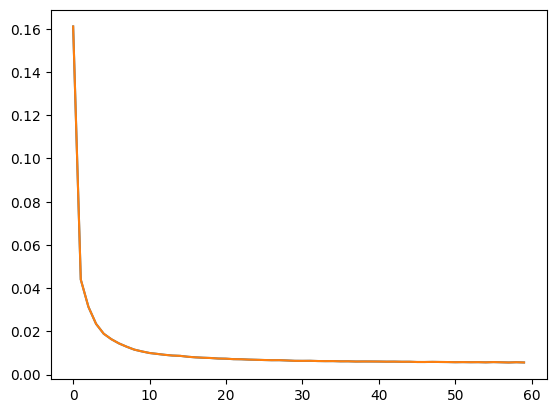


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 111, 190, 270, 349]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [349, 270, 190, 111, 32]}, 'max_epochs': 60, 'nickname': 'bottleneck_32_depth6', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 111, 190, 270, 349, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=349, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=349, out_features=270, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=27

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 320 K  | train
2 | decoder       | MLP     | 321 K  | train
--------------------------------------------------
642 K     Trainable params
0         Non-trainable params
642 K     Total params
2.568     Total estimated model params size (MB)
25        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth6_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth6_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth6_v1__reconstructed_outputs.csv


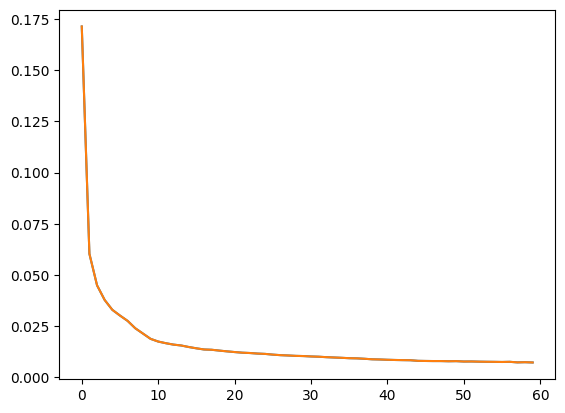


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 88, 145, 202, 258, 315, 372]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [372, 315, 258, 202, 145, 88, 32]}, 'max_epochs': 60, 'nickname': 'bottleneck_32_depth8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 88, 145, 202, 258, 315, 372, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=372, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=372, out_features=315, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
     

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 456 K  | train
2 | decoder       | MLP     | 456 K  | train
--------------------------------------------------
913 K     Trainable params
0         Non-trainable params
913 K     Total params
3.653     Total estimated model params size (MB)
33        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth8_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth8_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth8_v1__reconstructed_outputs.csv


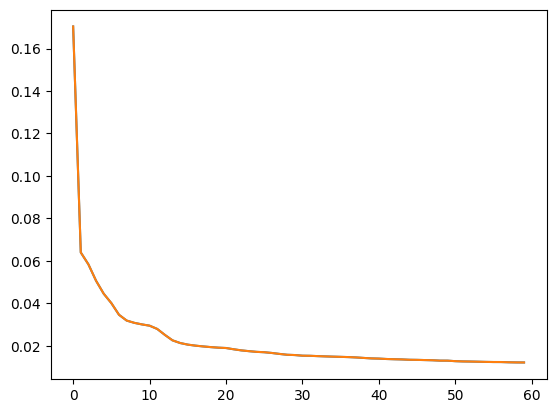

In [59]:
# Set the seed
set_random_seeds(seed=random_seed_number)
# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        },
        "decoder": {
            "sizes":  "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}

data_nickname = "census_geodemo"
# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    _depth = len(encoder_layer_size) + 1  # Number of layers is depth + 1 (input layer)
    ae_nickname = f"bottleneck_{_latent_size}_depth{_depth}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 278]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [278, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth3', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 278, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=278, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=278, out_features=128, bias=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 155 K  | train
2 | decoder       | MLP     | 155 K  | train
--------------------------------------------------
310 K     Trainable params
0         Non-trainable params
310 K     Total params
1.243     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth3_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth3_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth3_v1__reconstructed_outputs.csv


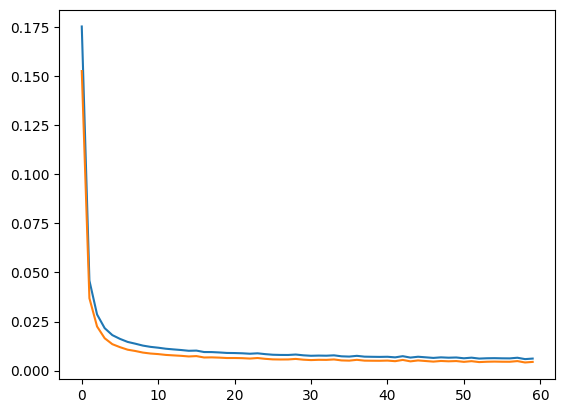


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 228, 328]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [328, 228, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 228, 328, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=328, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=328, out_features=

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 245 K  | train
2 | decoder       | MLP     | 245 K  | train
--------------------------------------------------
491 K     Trainable params
0         Non-trainable params
491 K     Total params
1.964     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth4_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth4_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth4_v1__reconstructed_outputs.csv


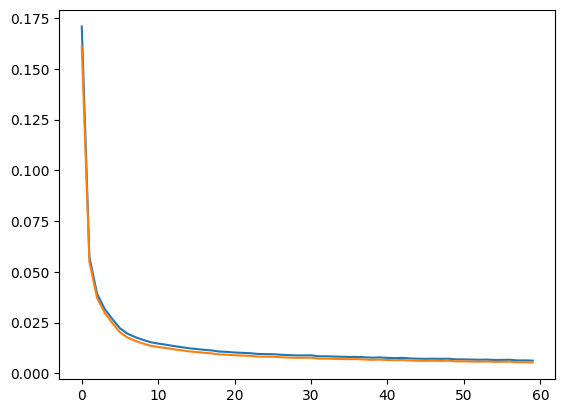


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 188, 248, 308, 368]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [368, 308, 248, 188, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth6', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 188, 248, 308, 368, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=368, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 419 K  | train
2 | decoder       | MLP     | 419 K  | train
--------------------------------------------------
839 K     Trainable params
0         Non-trainable params
839 K     Total params
3.357     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth6_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth6_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth6_v1__reconstructed_outputs.csv


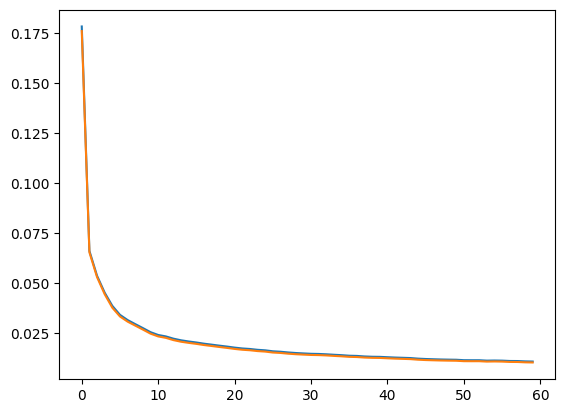


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 171, 214, 257, 300, 343, 386]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [386, 343, 300, 257, 214, 171, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 171, 214, 257, 300, 343, 386, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=386, bias=True)
      (1): LeakyReLU(negative_

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 593 K  | train
2 | decoder       | MLP     | 593 K  | train
--------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.747     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth8_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth8_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth8_v1__reconstructed_outputs.csv


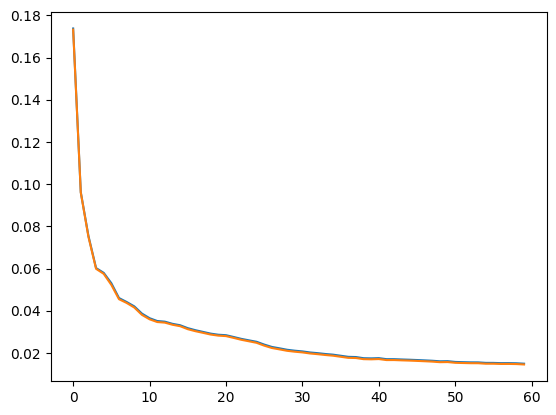


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 161, 194, 228, 261, 295, 328, 362, 395]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [395, 362, 328, 295, 261, 228, 194, 161, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth10', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 161, 194, 228, 261, 295, 328, 362, 395, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=395, bias=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 762 K  | train
2 | decoder       | MLP     | 763 K  | train
--------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
6.104     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth10_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth10_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth10_v1__reconstructed_outputs.csv


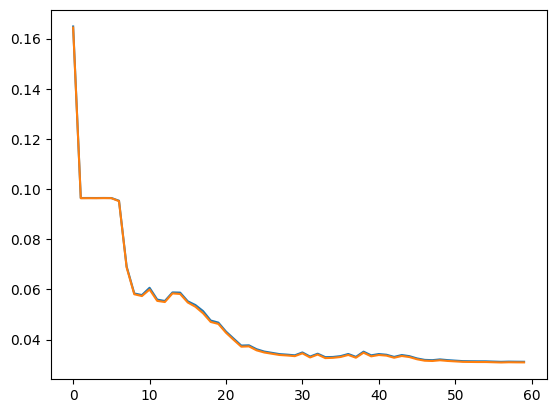


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 155, 182, 210, 237, 264, 292, 319, 346, 374, 401]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [401, 374, 346, 319, 292, 264, 237, 210, 182, 155, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth12', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'use_covariance_loss': False, 'decoder_sizes': [128, 155, 182, 210, 237, 264, 292, 319, 346, 374, 401, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 933 K  | train
2 | decoder       | MLP     | 933 K  | train
--------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.469     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth12_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth12_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparse__bottleneck_128_depth12_v1__reconstructed_outputs.csv


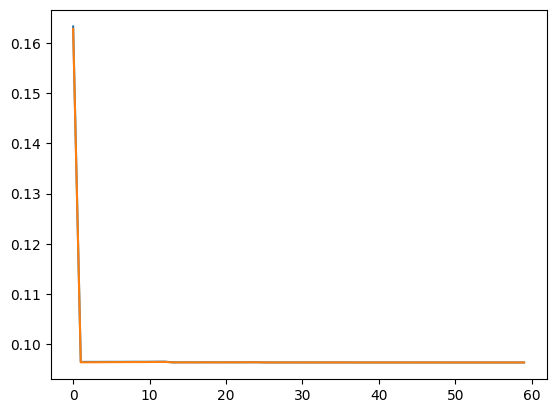

In [19]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparse"



# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    _depth = len(encoder_layer_size) + 1  # Number of layers is depth + 1 (input layer)
    ae_nickname = f"bottleneck_{_latent_size}_depth{_depth}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 278]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [278, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth3', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 278, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=278, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=278, out_features=128, bias=True)
      (3): TopK(
        (postact_fn): Identity()
      

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 155 K  | train
2 | decoder       | MLP     | 155 K  | train
--------------------------------------------------
310 K     Trainable params
0         Non-trainable params
310 K     Total params
1.243     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth3_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth3_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth3_v1__reconstructed_outputs.csv


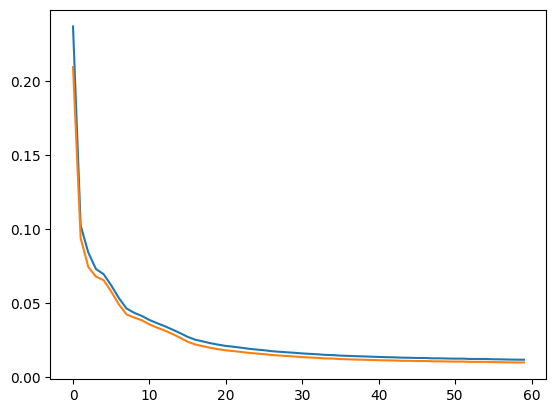


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 228, 328]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [328, 228, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth4', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 228, 328, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=328, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=328, out_features=228, bias=True)
      (3): LeakyReLU(negative_slope=0.01)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 245 K  | train
2 | decoder       | MLP     | 245 K  | train
--------------------------------------------------
491 K     Trainable params
0         Non-trainable params
491 K     Total params
1.964     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth4_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth4_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth4_v1__reconstructed_outputs.csv


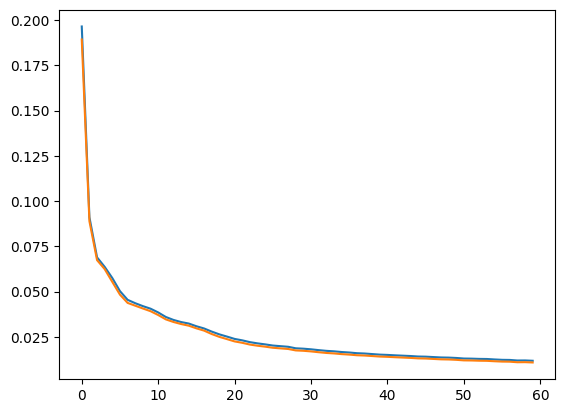


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 188, 248, 308, 368]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [368, 308, 248, 188, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth6', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 188, 248, 308, 368, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=368, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=368, out_features=308, bias=True)
      (3): 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 419 K  | train
2 | decoder       | MLP     | 419 K  | train
--------------------------------------------------
839 K     Trainable params
0         Non-trainable params
839 K     Total params
3.357     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth6_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth6_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth6_v1__reconstructed_outputs.csv


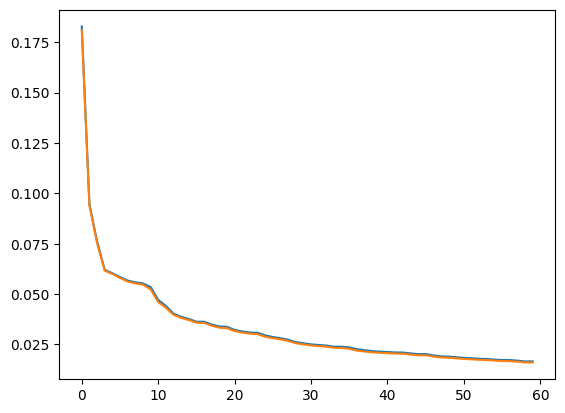


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 171, 214, 257, 300, 343, 386]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [386, 343, 300, 257, 214, 171, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth8', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 171, 214, 257, 300, 343, 386, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=386, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=386, out_featur

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 593 K  | train
2 | decoder       | MLP     | 593 K  | train
--------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.747     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth8_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth8_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth8_v1__reconstructed_outputs.csv


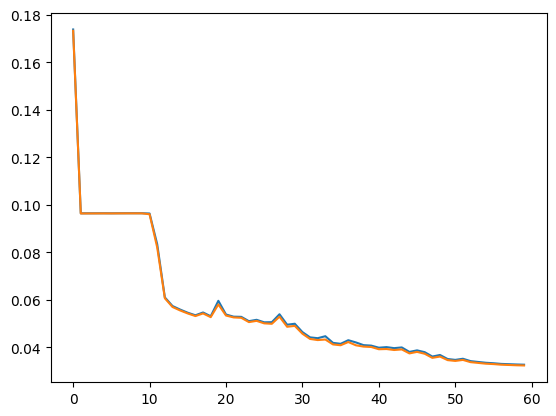


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 161, 194, 228, 261, 295, 328, 362, 395]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [395, 362, 328, 295, 261, 228, 194, 161, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth10', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 161, 194, 228, 261, 295, 328, 362, 395, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=395, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Lin

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 762 K  | train
2 | decoder       | MLP     | 763 K  | train
--------------------------------------------------
1.5 M     Trainable params
0         Non-trainable params
1.5 M     Total params
6.104     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth10_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth10_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth10_v1__reconstructed_outputs.csv


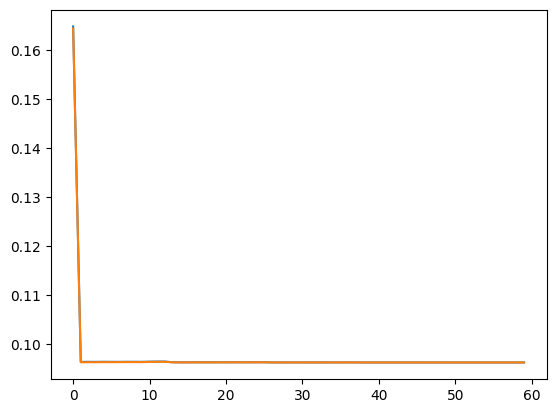


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [128, 155, 182, 210, 237, 264, 292, 319, 346, 374, 401]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [401, 374, 346, 319, 292, 264, 237, 210, 182, 155, 128], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 64}}, 'max_epochs': 60, 'nickname': 'bottleneck_128_depth12', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/engcensus_cleaned_scaled.parquet'}, 'working_dir': '../engcensus/60epoch_depthscan_alleng_lin'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 64, 'decoder_sizes': [128, 155, 182, 210, 237, 264, 292, 319, 346, 374, 401, 429], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=429, out_features=401, bias=True)
      (1): LeakyReLU(negat

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 933 K  | train
2 | decoder       | MLP     | 933 K  | train
--------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.469     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder_sasha/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstruction errors saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth12_v1__recon_error.csv
Original inputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth12_v1__original_inputs.csv
Reconstructed outputs saved to ../engcensus/60epoch_depthscan_alleng_lin/census_geodemo_sparsecov__bottleneck_128_depth12_v1__reconstructed_outputs.csv


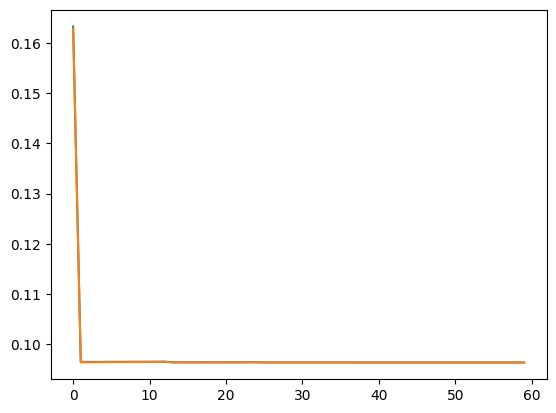

In [20]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": cleaned_data_path,
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparsecov"

# Generate YAML files with varying latent space sizes
for encoder_layer_size in encoder_layer_sizes:
    _latent_size = encoder_layer_size[-1]  # Last element is the bottleneck size
    _depth = len(encoder_layer_size) + 1  # Number of layers is depth + 1 (input layer)
    ae_nickname = f"bottleneck_{_latent_size}_depth{_depth}"
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_layer_size
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_layer_size[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)

In [ ]:


# Initialize lists to store RMSE and MAE
errors = {}

data_table = df_scaled.copy()
# Set the index to 'OA'
data_table = data_table.set_index('OA')
n_features = data_table.shape[1]
data = data_table
def compute_errors(original, reconstructed):
    """Compute RMSE and MAE between original and reconstructed data."""
    error = original - reconstructed
    return np.sqrt(np.mean(error ** 2)), np.mean(np.abs(error))

# Fit PCA once with the maximum number of components
pca = PCA(n_components=n_features - 1)
transformed = pca.fit_transform(data)

# Process PCA reconstruction
errors["PCA"] = {"rmse": [], "mae": []}
n = bottleneck_size
reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
print(len(pca.mean_))
#save the reconstructed data
pd.DataFrame(reconstructed_pca, index=data.index, columns=data.columns).to_csv(f"../data/PCA/{n}_components.csv")
rmse, mae = compute_errors(data, reconstructed_pca)
errors["PCA"]["rmse"].append(rmse)
errors["PCA"]["mae"].append(mae)



Processing PCA:   0%|          | 0/7 [00:00<?, ?it/s]

429


Processing PCA:  14%|█▍        | 1/7 [01:29<08:58, 89.78s/it]

429


Processing PCA:  29%|██▊       | 2/7 [03:00<07:31, 90.37s/it]

...

Processing PCA:  71%|███████▏  | 5/7 [07:23<02:56, 88.03s/it]

429


Processing PCA:  86%|████████▌ | 6/7 [08:49<01:27, 87.27s/it]

429


Processing PCA: 100%|██████████| 7/7 [10:16<00:00, 88.04s/it]


In [ ]:
data_table = pd.read_parquet(cleaned_data_path)
# Set the index to 'OA'
data_table = data_table.set_index('OA')
n_features = data_table.shape[1]
data = data_table

# Initialize lists to store RMSE and MAE
errors = {}
# reco_err = pd.read_csv("../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_128_depth3_v1__recon_error.csv")
def compute_errors(original, reconstructed):
    """Compute RMSE and MAE between original and reconstructed data."""
    error = original - reconstructed
    #print any nans series
    if error.isna().any().any():
        print("Nans in error")
        print(error)
    return np.sqrt(np.mean(error ** 2)), np.mean(np.abs(error))

def load_reconstructed_data(file_path):
    """Load reconstructed data from a CSV file."""
    return pd.read_csv(file_path, index_col="ID")

errs = []
for depth in depths:
    # Load the reconstruction error
    reco_err = pd.read_csv(f"../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_128_depth{depth}_v1__recon_error.csv")

    reco_err = reco_err.set_index('ID')
    print(np.sqrt(reco_err['Reconstruction_Error'].mean()))
    # Compute RMSE and MAE
    errs.append(np.sqrt(reco_err['Reconstruction_Error'].mean()))


0.009002618795599172
0.012375566296624596
0.012765222602629968
0.02078185487915313
0.026977372021246903
0.032200232268122374
0.05255678748807631


0.009002618795599172
0.012375566296624596
0.012765222602629968
0.02078185487915313
0.026977372021246903
0.032200232268122374
0.05255678748807631
0.023696014519384256
0.019816277618805472
0.018784857284139766
0.021863875036996338
0.027785017428438363


Text(0, 0.5, 'RMSE')

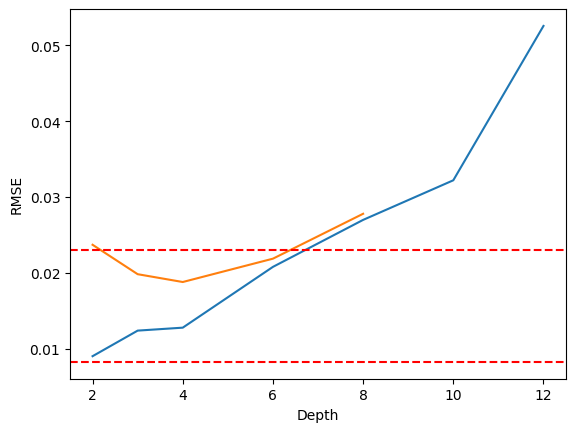

In [63]:
errs = []
depths = [2,3,4,6,8,10,12]
for depth in depths:
    # Load the reconstruction error
    reco_err = pd.read_csv(f"../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_128_depth{depth}_v1__recon_error.csv")

    reco_err = reco_err.set_index('ID')
    print(np.sqrt(reco_err['Reconstruction_Error'].mean()))
    # Compute RMSE and MAE
    errs.append(np.sqrt(reco_err['Reconstruction_Error'].mean()))


reconstructed_pca = pd.read_csv(f"../data/PCA/{128}_components.csv",index_col=0)
pca_rmse, mae = compute_errors(data, reconstructed_pca)

plt.plot(depths, errs)
#load the PCA error for the epoch
plt.axhline(y=pca_rmse, color='r', linestyle='--', label="PCA RMSE")
plt.xlabel("Depth")
plt.ylabel("RMSE")


errs = []
depths = [2,3,4,6,8]
for depth in depths:
    # Load the reconstruction error
    reco_err = pd.read_csv(f"../engcensus/60epoch_depthscan_alleng_lin/census_geodemo__bottleneck_32_depth{depth}_v1__recon_error.csv")

    reco_err = reco_err.set_index('ID')
    print(np.sqrt(reco_err['Reconstruction_Error'].mean()))
    # Compute RMSE and MAE
    errs.append(np.sqrt(reco_err['Reconstruction_Error'].mean()))


reconstructed_pca = pd.read_csv(f"../data/PCA/{32}_components.csv",index_col=0)
pca_rmse, mae = compute_errors(data, reconstructed_pca)

plt.plot(depths, errs)
#load the PCA error for the epoch
plt.axhline(y=pca_rmse, color='r', linestyle='--', label="PCA RMSE")
plt.xlabel("Depth")
plt.ylabel("RMSE")

In [55]:
reconstructed_pca 

,OA,ts0010002_PCT,ts0010003_PCT,ts0020002_PCT,ts0020003_PCT,ts0020004_PCT,ts0020005_PCT,ts0020006_PCT,ts0020007_PCT,ts0020008_PCT,...,ts0670007_PCT,ts0670008_PCT,ts0680002_PCT,ts0680003_PCT,ts0750002_PCT,ts0750003_PCT,ts0750004_PCT,ts0750005_PCT,ts0750006_PCT,ts0750007_PCT
0,E00060274,1.000849,-0.000849,0.501862,0.303105,0.301055,0.298049,0.003001,0.002036,0.000862,...,0.144920,0.020870,0.269007,0.730993,0.255146,0.013456,0.235892,0.381667,0.113289,0.000530
1,E00060275,1.002374,-0.002374,0.504305,0.335422,0.334546,0.332163,0.002370,0.000879,0.000397,...,0.180204,0.019598,0.245486,0.754514,0.217038,0.028587,0.279657,0.320554,0.150481,0.003682
2,E00060276,0.999159,0.000841,0.370624,0.443339,0.441497,0.438944,0.002550,0.001850,0.000732,...,0.175189,0.028634,0.173284,0.826716,0.290741,0.003185,0.377585,0.294410,0.035847,-0.001742
3,E00060277,1.002768,-0.002768,0.459370,0.367575,0.366673,0.364535,0.002134,0.000902,0.000509,...,0.166233,0.022602,0.247126,0.752874,0.337250,0.005191,0.296079,0.235996,0.122852,0.002654
4,E00060279,1.002023,-0.002023,0.381694,0.413742,0.412223,0.409877,0.002356,0.001516,0.000450,...,0.155290,0.027789,0.200699,0.799301,0.281987,0.018108,0.342008,0.240232,0.111858,0.005829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188875,W00006938,1.003299,-0.003299,0.240082,0.543452,0.540435,0.537270,0.003172,0.003025,0.000937,...,0.396855,0.026594,0.158790,0.841210,0.331460,0.019423,0.273310,0.208482,0.160684,0.006651
188876,W00006940,0.998938,0.001062,0.309149,0.510903,0.509527,0.506759,0.002777,0.001373,0.000552,...,0.275341,0.024696,0.180673,0.819327,0.261722,0.032256,0.277187,0.283053,0.143138,0.002675
188877,W00006941,0.997923,0.002077,0.397673,0.365975,0.364145,0.361716,0.002442,0.001828,0.000617,...,0.192640,0.035493,0.135422,0.864578,0.329116,0.025581,0.211990,0.279294,0.150021,0.004028
188878,W00006942,0.997157,0.002843,0.473921,0.331790,0.330058,0.327800,0.002272,0.001723,0.000877,...,0.167898,0.024094,0.239670,0.760330,0.267066,0.030249,0.166291,0.418160,0.116413,0.001834


In [ ]:
err

np.float64(0.0027622159110668146)

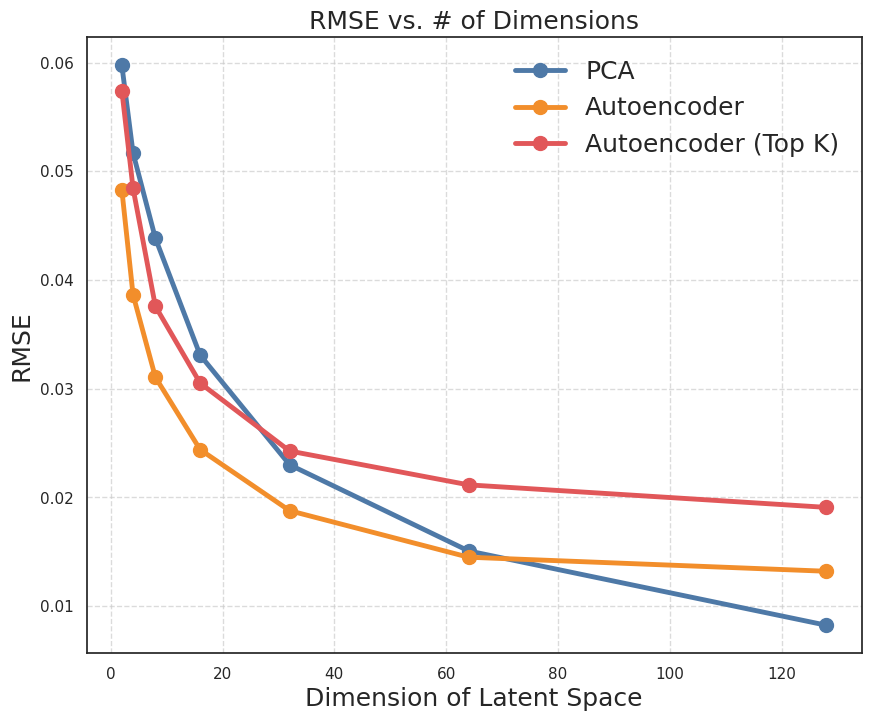

In [ ]:
import matplotlib.pyplot as plt

def plot_errors(metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    colors = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC949"]  # Good contrast & distinct colors
    plt.figure(figsize=(10, 8))
    
    for i, (label, data) in enumerate(errors.items()):
        plt.plot(
            bottleneck_sizes, data[metric], 
            marker='o', markersize=10, linewidth=3.5, 
            label=label, color=colors[i % len(colors)]
        )
    
    plt.xlabel("Dimension of Latent Space", fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=18, frameon=False)
    plt.grid(True, linestyle="--", alpha=0.7)

# Generate plot
plot_errors("rmse", "RMSE", "RMSE vs. # of Dimensions")
plt.show()


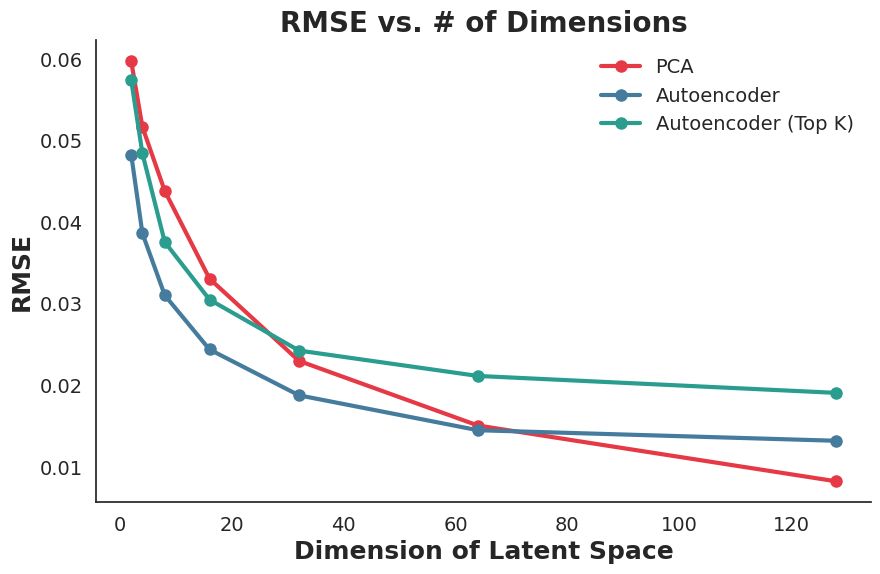

In [ ]:
import matplotlib.pyplot as plt

def plot_errors(metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    plt.figure(figsize=(10, 6))  # Adjust figure size
    colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#264653"]  # Custom color palette

    for (label, data), color in zip(errors.items(), colors):
        plt.plot(bottleneck_sizes, data[metric], 
                 marker='o', markersize=8, linewidth=3, 
                 label=label, color=color)

    plt.xlabel("Dimension of Latent Space", fontsize=18, fontweight="bold")
    plt.ylabel(ylabel, fontsize=18, fontweight="bold")
    plt.title(title, fontsize=20, fontweight="bold")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, frameon=False, loc="best")
    
    # Remove unnecessary spines
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

# Generate plots
plot_errors("rmse", "RMSE", "RMSE vs. # of Dimensions")
plt.show()
